# Analysis of our Users

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
user_features = pd.read_csv("data/data_preprocessed/user_features.csv")

In [3]:
user_features.columns

Index(['user_id', 'gender', 'married', 'has_children', 'home_country',
       'home_city', 'home_airport', 'age', 'state', 'num_session', 'num_trips',
       'num_flights', 'num_hotels', 'booking_discount_rate', 'average_seats',
       'average_checked_bags', 'average_seat_price', 'weekend_trip_ratio',
       'average_nights', 'total_flight_cost', 'total_hotels_cost'],
      dtype='str')

In [4]:
user_features["conversion_rate"] = user_features["num_trips"]/user_features["num_session"]

In [5]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,state,num_session,...,num_hotels,booking_discount_rate,average_seats,average_checked_bags,average_seat_price,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,conversion_rate
0,94883,F,True,False,usa,kansas city,MCI,54,Missouri,8,...,2,0.0,1.5,0.5,276.252500,0.50,1.0,864.090,230.00,0.250
1,101486,F,True,True,usa,tacoma,TCM,53,Washington,8,...,2,0.0,1.0,0.0,189.910000,1.00,4.0,189.910,2199.00,0.250
2,101961,F,True,False,usa,boston,BOS,46,Massachusetts,8,...,5,0.2,1.0,0.4,248.532000,0.20,3.8,1237.693,2429.00,0.625
3,106907,F,True,True,usa,miami,TNT,47,Florida,8,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000
4,118043,F,False,True,usa,los angeles,LAX,54,California,8,...,4,0.6,2.0,1.0,445.847222,0.25,5.5,2339.290,5616.45,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5993,780167,F,True,True,usa,los angeles,LAX,52,California,8,...,1,0.5,1.5,0.0,448.535000,0.00,1.0,1122.106,220.00,0.250
5994,785186,F,True,True,usa,little rock,LIT,47,Arkansas,8,...,2,0.0,1.0,0.0,176.675000,1.00,1.0,353.350,291.00,0.250
5995,792549,F,False,False,usa,kansas city,MCI,48,Missouri,8,...,1,0.0,1.0,0.5,259.792500,1.00,4.0,1039.170,144.00,0.500
5996,811077,F,True,True,usa,knoxville,TYS,47,Tennessee,8,...,1,0.0,1.0,0.0,579.790000,0.00,6.0,579.790,852.00,0.125


In [6]:
user_features["age"] = user_features["age"] - 3 # upsi

# Age vs. Weekend

In [7]:
user_features["age"].nunique()

71

<Axes: xlabel='age', ylabel='weekend_trip_ratio'>

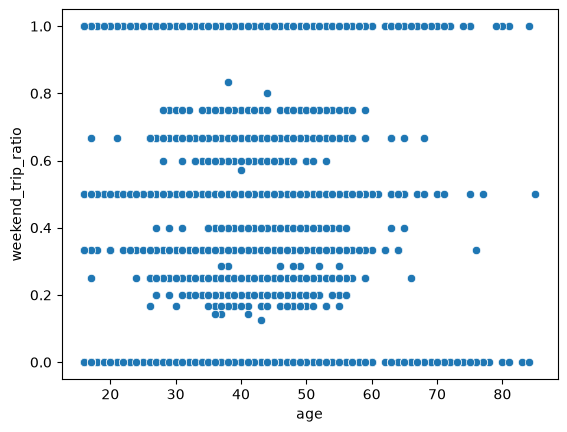

In [8]:
sns.scatterplot(user_features, x="age", y="weekend_trip_ratio")

<Axes: xlabel='age', ylabel='weekend_trip_ratio'>

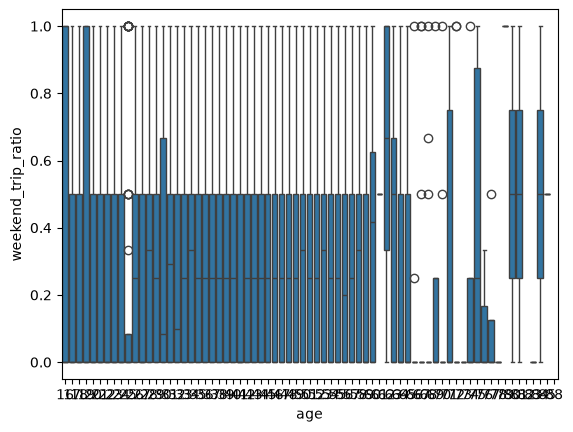

In [9]:
sns.boxplot(user_features, x="age", y="weekend_trip_ratio")

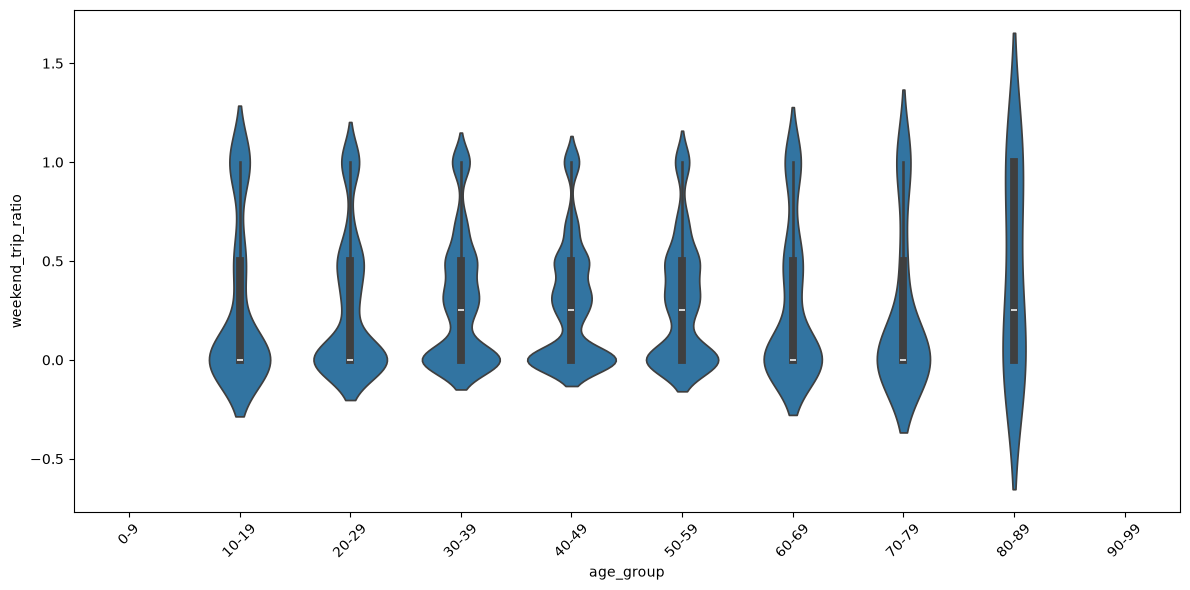

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create 10-year age bins
bins = list(range(0, 101, 10))  # [0, 10, 20, ..., 100]
labels = [f"{b}-{b+9}" for b in bins[:-1]]  # ['0-9', '10-19', ...]

user_features["age_group"] = pd.cut(
    user_features["age"],
    bins=bins,
    labels=labels,
    right=False  # so 20 falls in "20-29", not "10-19"
)

# Plot
plt.figure(figsize=(12, 6))
sns.violinplot(data=user_features, x="age_group", y="weekend_trip_ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
user_features["weekend_trip_ratio"].value_counts()

weekend_trip_ratio
0.000000    2407
0.500000     816
0.333333     615
1.000000     509
0.250000     352
0.666667     263
0.200000     129
0.400000     102
0.750000      59
0.600000      42
0.166667      28
0.285714       7
0.142857       3
0.833333       1
0.800000       1
0.571429       1
0.125000       1
Name: count, dtype: int64

In [12]:
user_features.columns

Index(['user_id', 'gender', 'married', 'has_children', 'home_country',
       'home_city', 'home_airport', 'age', 'state', 'num_session', 'num_trips',
       'num_flights', 'num_hotels', 'booking_discount_rate', 'average_seats',
       'average_checked_bags', 'average_seat_price', 'weekend_trip_ratio',
       'average_nights', 'total_flight_cost', 'total_hotels_cost',
       'conversion_rate', 'age_group'],
      dtype='str')

# Age Analysis

<Axes: xlabel='age', ylabel='Count'>

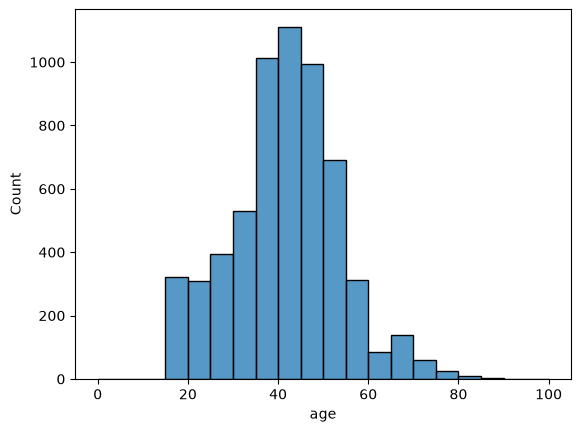

In [13]:
sns.histplot(user_features, x="age", bins=range(0, 101, 5))

<Axes: xlabel='age', ylabel='Count'>

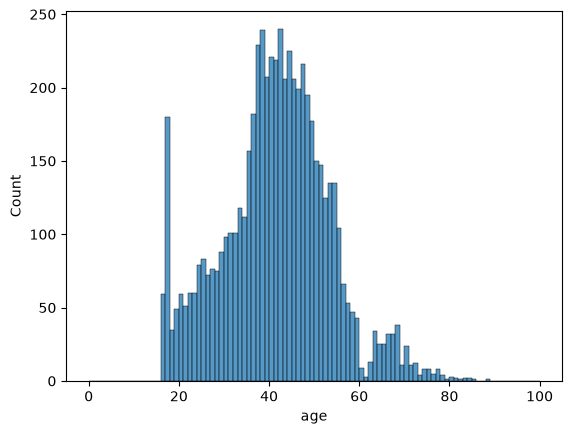

In [14]:
sns.histplot(user_features, x="age", bins=range(0, 101, 1))

<Axes: xlabel='gender', ylabel='percent'>

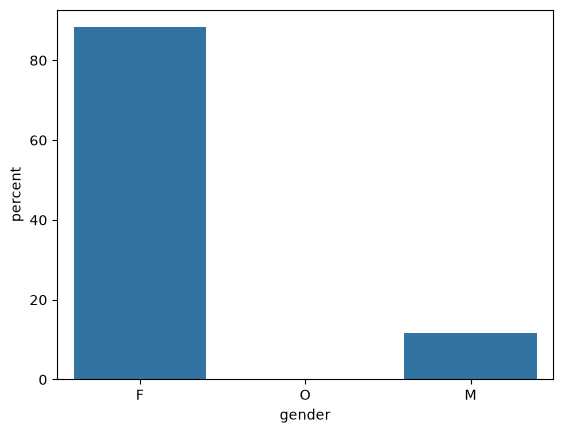

In [15]:
sns.countplot(user_features, x="gender", stat="percent")

In [16]:
user_features["gender"].value_counts()

gender
F    5292
M     695
O      11
Name: count, dtype: int64

# Spent Analysis

In [17]:
user_features.columns

Index(['user_id', 'gender', 'married', 'has_children', 'home_country',
       'home_city', 'home_airport', 'age', 'state', 'num_session', 'num_trips',
       'num_flights', 'num_hotels', 'booking_discount_rate', 'average_seats',
       'average_checked_bags', 'average_seat_price', 'weekend_trip_ratio',
       'average_nights', 'total_flight_cost', 'total_hotels_cost',
       'conversion_rate', 'age_group'],
      dtype='str')

<Axes: xlabel='average_seat_price', ylabel='Count'>

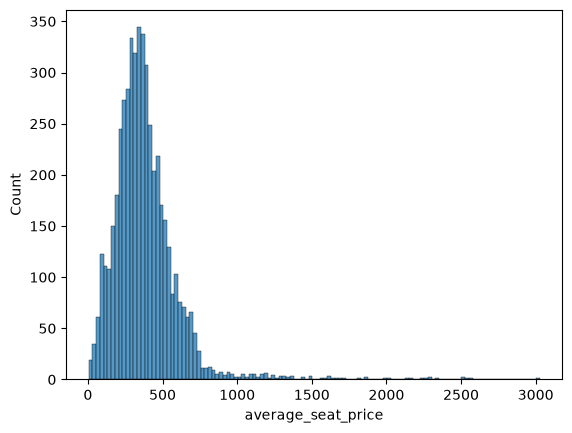

In [18]:
sns.histplot(user_features, x= "average_seat_price")

<Axes: xlabel='age', ylabel='average_seat_price'>

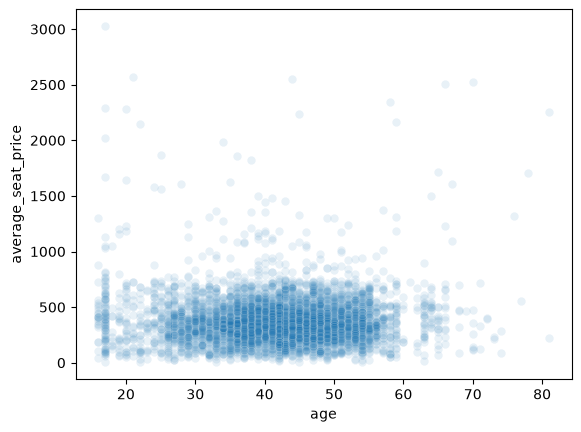

In [19]:
sns.scatterplot(user_features, x="age", y="average_seat_price", alpha=0.1)

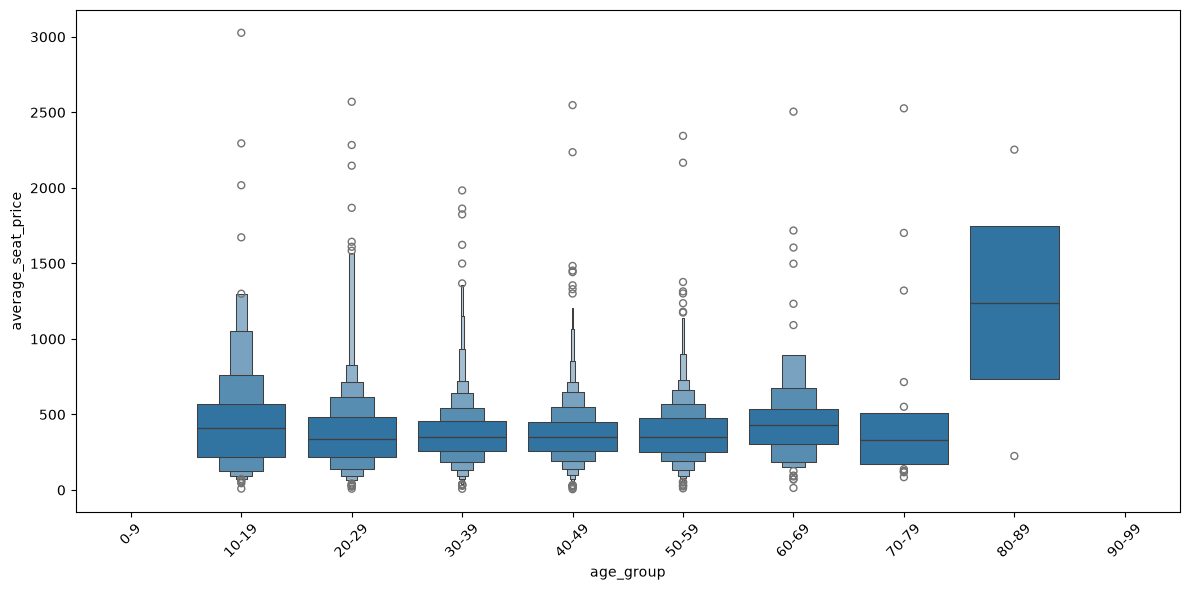

In [20]:
# Create 10-year age bins
bins = list(range(0, 101, 10))  # [0, 10, 20, ..., 100]
labels = [f"{b}-{b+9}" for b in bins[:-1]]  # ['0-9', '10-19', ...]

user_features["age_group"] = pd.cut(
    user_features["age"],
    bins=bins,
    labels=labels,
    right=False  # so 20 falls in "20-29", not "10-19"
)

# Plot
plt.figure(figsize=(12, 6))
sns.boxenplot(data=user_features, x="age_group", y="average_seat_price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

(0.0, 8000.0)

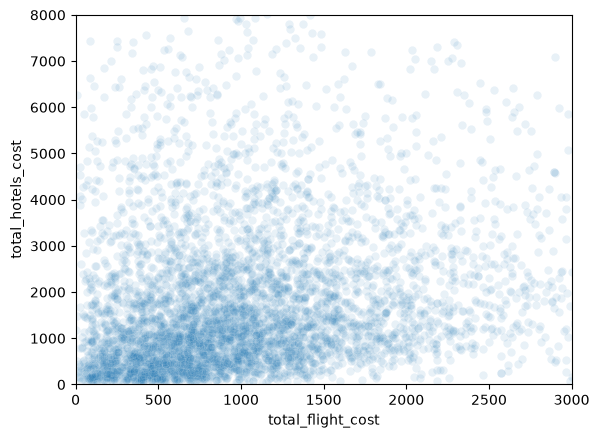

In [21]:
sns.scatterplot(user_features, x="total_flight_cost", y="total_hotels_cost", alpha=0.1)
plt.xlim(0,3000)
plt.ylim(0,8000)

In [22]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,state,num_session,...,booking_discount_rate,average_seats,average_checked_bags,average_seat_price,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,conversion_rate,age_group
0,94883,F,True,False,usa,kansas city,MCI,51,Missouri,8,...,0.0,1.5,0.5,276.252500,0.50,1.0,864.090,230.00,0.250,50-59
1,101486,F,True,True,usa,tacoma,TCM,50,Washington,8,...,0.0,1.0,0.0,189.910000,1.00,4.0,189.910,2199.00,0.250,50-59
2,101961,F,True,False,usa,boston,BOS,43,Massachusetts,8,...,0.2,1.0,0.4,248.532000,0.20,3.8,1237.693,2429.00,0.625,40-49
3,106907,F,True,True,usa,miami,TNT,44,Florida,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,40-49
4,118043,F,False,True,usa,los angeles,LAX,51,California,8,...,0.6,2.0,1.0,445.847222,0.25,5.5,2339.290,5616.45,0.625,50-59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5993,780167,F,True,True,usa,los angeles,LAX,49,California,8,...,0.5,1.5,0.0,448.535000,0.00,1.0,1122.106,220.00,0.250,40-49
5994,785186,F,True,True,usa,little rock,LIT,44,Arkansas,8,...,0.0,1.0,0.0,176.675000,1.00,1.0,353.350,291.00,0.250,40-49
5995,792549,F,False,False,usa,kansas city,MCI,45,Missouri,8,...,0.0,1.0,0.5,259.792500,1.00,4.0,1039.170,144.00,0.500,40-49
5996,811077,F,True,True,usa,knoxville,TYS,44,Tennessee,8,...,0.0,1.0,0.0,579.790000,0.00,6.0,579.790,852.00,0.125,40-49


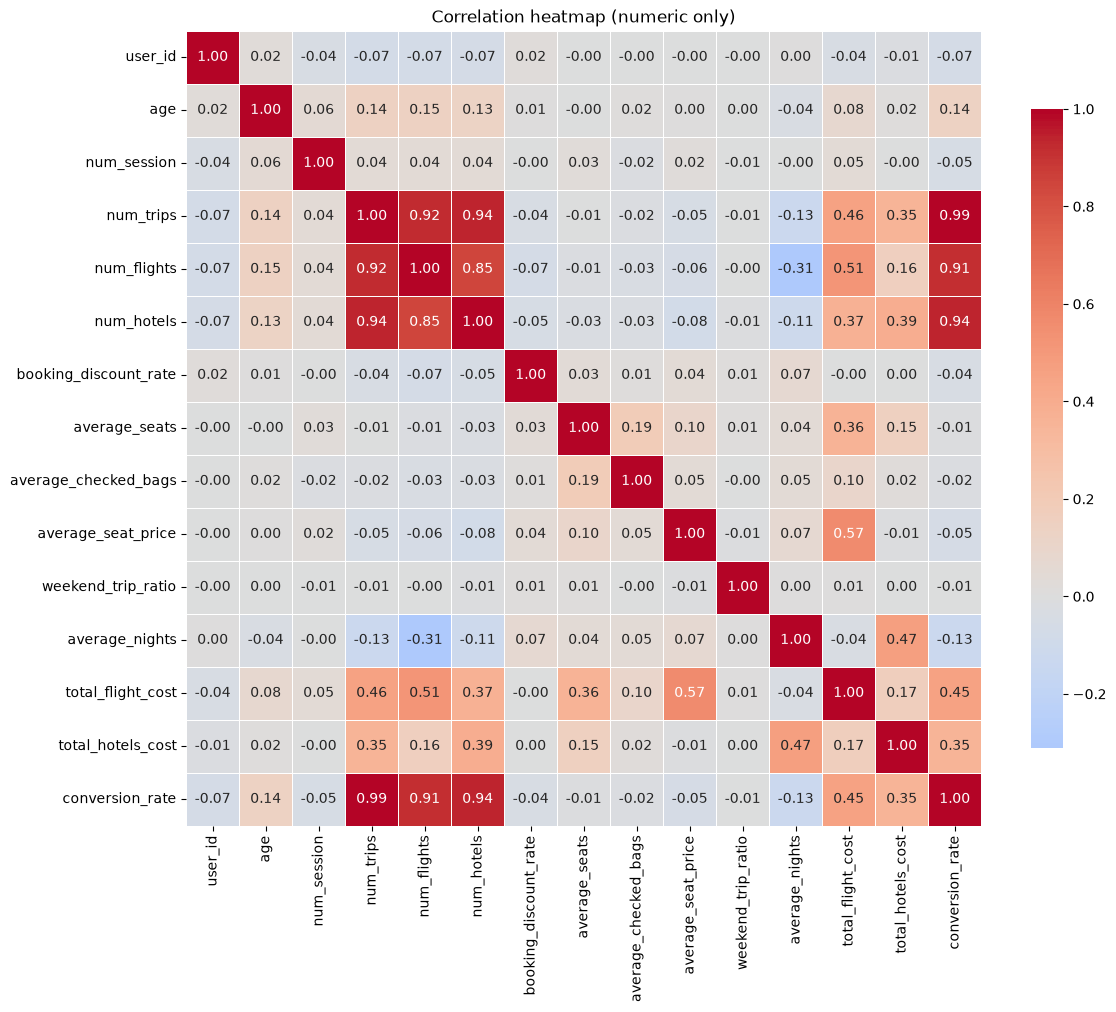

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr = user_features.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': .8})
plt.title('Correlation heatmap (numeric only)')
plt.tight_layout()
plt.show()

<Axes: xlabel='num_flights', ylabel='total_flight_cost'>

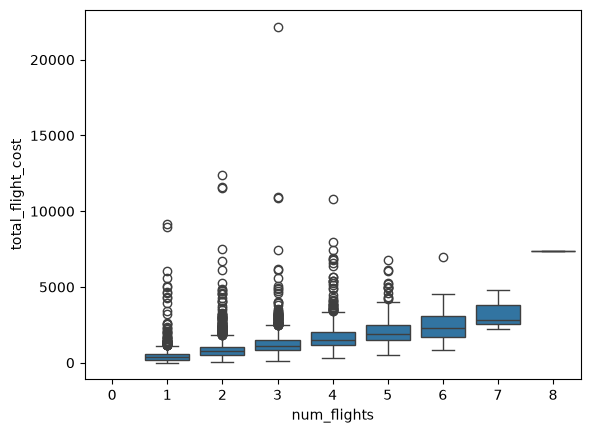

In [24]:
sns.boxplot(user_features, x ="num_flights", y="total_flight_cost")

# Average Duration Stay

In [25]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,state,num_session,...,booking_discount_rate,average_seats,average_checked_bags,average_seat_price,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,conversion_rate,age_group
0,94883,F,True,False,usa,kansas city,MCI,51,Missouri,8,...,0.0,1.5,0.5,276.252500,0.50,1.0,864.090,230.00,0.250,50-59
1,101486,F,True,True,usa,tacoma,TCM,50,Washington,8,...,0.0,1.0,0.0,189.910000,1.00,4.0,189.910,2199.00,0.250,50-59
2,101961,F,True,False,usa,boston,BOS,43,Massachusetts,8,...,0.2,1.0,0.4,248.532000,0.20,3.8,1237.693,2429.00,0.625,40-49
3,106907,F,True,True,usa,miami,TNT,44,Florida,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,40-49
4,118043,F,False,True,usa,los angeles,LAX,51,California,8,...,0.6,2.0,1.0,445.847222,0.25,5.5,2339.290,5616.45,0.625,50-59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5993,780167,F,True,True,usa,los angeles,LAX,49,California,8,...,0.5,1.5,0.0,448.535000,0.00,1.0,1122.106,220.00,0.250,40-49
5994,785186,F,True,True,usa,little rock,LIT,44,Arkansas,8,...,0.0,1.0,0.0,176.675000,1.00,1.0,353.350,291.00,0.250,40-49
5995,792549,F,False,False,usa,kansas city,MCI,45,Missouri,8,...,0.0,1.0,0.5,259.792500,1.00,4.0,1039.170,144.00,0.500,40-49
5996,811077,F,True,True,usa,knoxville,TYS,44,Tennessee,8,...,0.0,1.0,0.0,579.790000,0.00,6.0,579.790,852.00,0.125,40-49


In [26]:
user_features["average_nights"].round().value_counts()

average_nights
2.0     1498
4.0      919
3.0      876
1.0      620
6.0      405
5.0      396
7.0      158
8.0      156
9.0       71
10.0      69
12.0      42
11.0      37
13.0      17
14.0      17
16.0      15
17.0       9
15.0       8
20.0       7
18.0       5
27.0       2
21.0       2
30.0       1
24.0       1
23.0       1
28.0       1
25.0       1
19.0       1
22.0       1
Name: count, dtype: int64

In [27]:
user_features["average_nights"].round()

0       1.0
1       4.0
2       4.0
3       NaN
4       6.0
       ... 
5993    1.0
5994    1.0
5995    4.0
5996    6.0
5997    NaN
Name: average_nights, Length: 5998, dtype: float64

<Axes: xlabel='average_nights', ylabel='Count'>

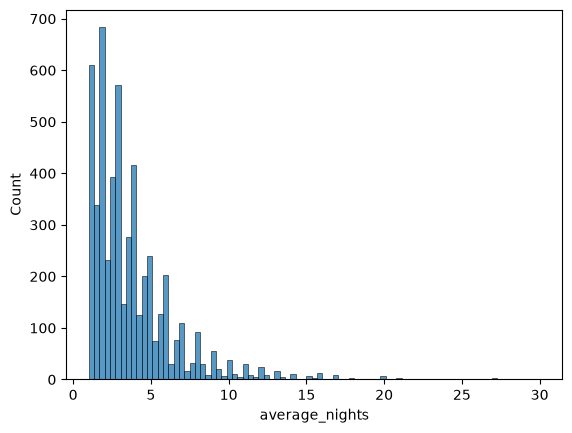

In [28]:
sns.histplot(user_features["average_nights"])

<Axes: xlabel='average_nights', ylabel='Count'>

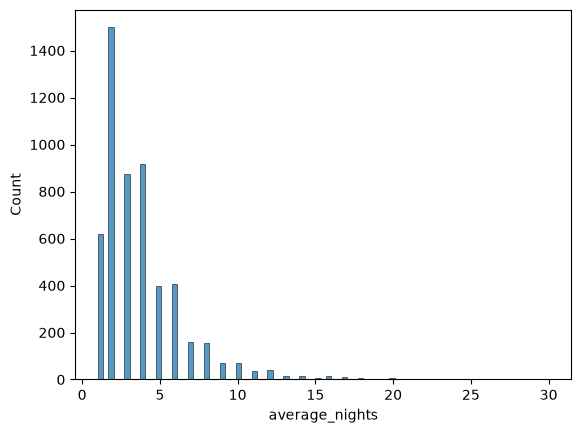

In [29]:
sns.histplot(user_features["average_nights"].round())

Interesing possible **New group** long stayers after a week.

# Conversion RAte

In [30]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,state,num_session,...,booking_discount_rate,average_seats,average_checked_bags,average_seat_price,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,conversion_rate,age_group
0,94883,F,True,False,usa,kansas city,MCI,51,Missouri,8,...,0.0,1.5,0.5,276.252500,0.50,1.0,864.090,230.00,0.250,50-59
1,101486,F,True,True,usa,tacoma,TCM,50,Washington,8,...,0.0,1.0,0.0,189.910000,1.00,4.0,189.910,2199.00,0.250,50-59
2,101961,F,True,False,usa,boston,BOS,43,Massachusetts,8,...,0.2,1.0,0.4,248.532000,0.20,3.8,1237.693,2429.00,0.625,40-49
3,106907,F,True,True,usa,miami,TNT,44,Florida,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,40-49
4,118043,F,False,True,usa,los angeles,LAX,51,California,8,...,0.6,2.0,1.0,445.847222,0.25,5.5,2339.290,5616.45,0.625,50-59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5993,780167,F,True,True,usa,los angeles,LAX,49,California,8,...,0.5,1.5,0.0,448.535000,0.00,1.0,1122.106,220.00,0.250,40-49
5994,785186,F,True,True,usa,little rock,LIT,44,Arkansas,8,...,0.0,1.0,0.0,176.675000,1.00,1.0,353.350,291.00,0.250,40-49
5995,792549,F,False,False,usa,kansas city,MCI,45,Missouri,8,...,0.0,1.0,0.5,259.792500,1.00,4.0,1039.170,144.00,0.500,40-49
5996,811077,F,True,True,usa,knoxville,TYS,44,Tennessee,8,...,0.0,1.0,0.0,579.790000,0.00,6.0,579.790,852.00,0.125,40-49


In [31]:

user_features["conversion_rate"].describe()

count    5998.000000
mean        0.315226
std         0.187506
min         0.000000
25%         0.125000
50%         0.333333
75%         0.444444
max         1.000000
Name: conversion_rate, dtype: float64

<Axes: xlabel='num_session', ylabel='num_trips'>

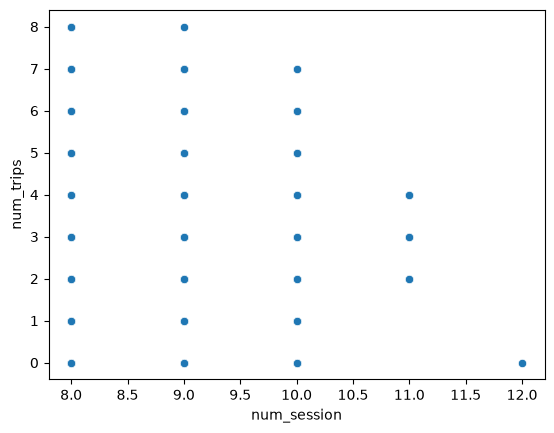

In [32]:
sns.scatterplot(user_features, x="num_session", y="num_trips")

In [33]:
user_features["conversion_rate"].describe()

count    5998.000000
mean        0.315226
std         0.187506
min         0.000000
25%         0.125000
50%         0.333333
75%         0.444444
max         1.000000
Name: conversion_rate, dtype: float64

<Axes: xlabel='conversion_rate', ylabel='Count'>

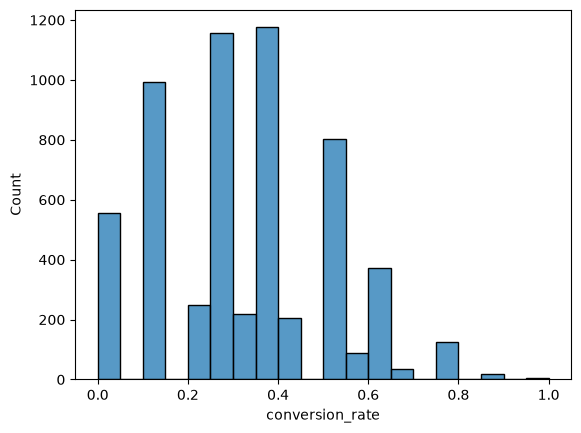

In [34]:
sns.histplot(user_features["conversion_rate"], binwidth=0.05)

In [52]:
user_features["total_spent"] = user_features["total_flight_cost"] + user_features["total_flight_cost"]

<Axes: xlabel='total_spent', ylabel='Count'>

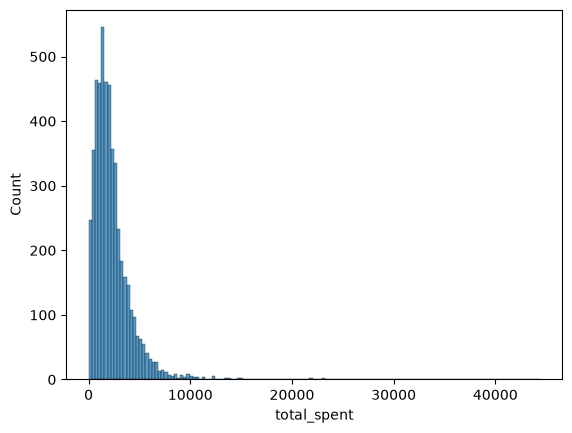

In [54]:
sns.histplot(user_features["total_spent"])

In [56]:
user_features["total_spent"].quantile(0.9)

np.float64(4446.3784000000005)

<Axes: xlabel='booking_discount_rate', ylabel='Count'>

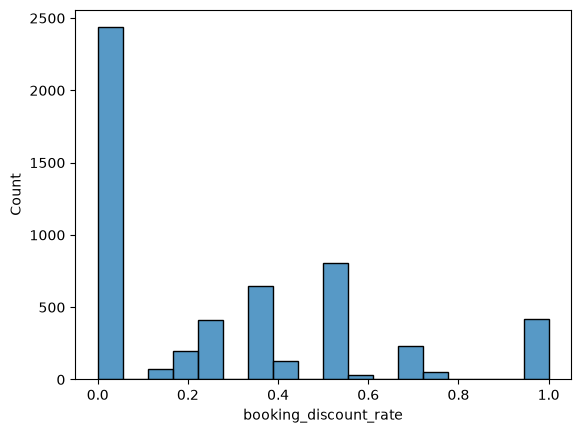

In [57]:
sns.histplot(user_features, x="booking_discount_rate")

<Axes: xlabel='age', ylabel='Count'>

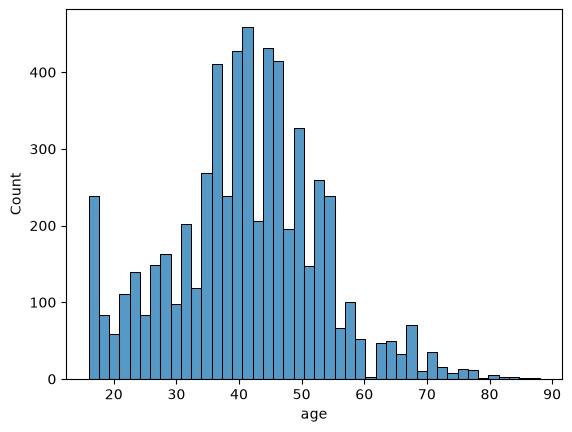

In [58]:
sns.histplot(user_features, x ="age")

<Axes: xlabel='average_seats', ylabel='Count'>

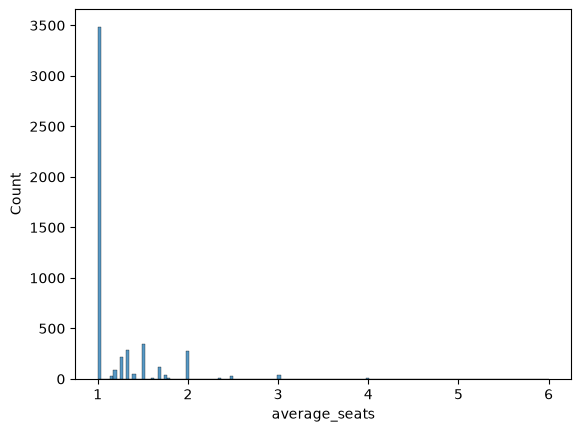

In [59]:
sns.histplot(user_features, x = "average_seats")

# Group Building

- long stayer: avg night >= 7 
- undecisive conversion rate < 0.2
- top spenders: >user_features["total_spent"].quantile(0.9)
- youngs age < 20
- retrired  age > 60
- discount buyer, booking_discount_rate > 0.8
- family travelers average_seats > 1.8 and has children

In [40]:
import numpy as np

In [61]:
user_features["group"] = None

In [62]:
user_features.loc[user_features["average_nights"]>7, "group"] = "Long Stayers"

In [64]:
user_features.loc[user_features["conversion_rate"]<0.2, "group"] = "Indecisive"

In [65]:
user_features.loc[user_features["total_spent"]>user_features["total_spent"].quantile(0.9), "group"] = "High Spenders"

In [70]:
# Youngs
user_features.loc[user_features["age"] < 20, "group"] = "Youngs"

# Retired
user_features.loc[user_features["age"] > 60, "group"] = "Retired"

# Discount buyer
user_features.loc[user_features["booking_discount_rate"] > 0.8, "group"] = "Discount buyer"

# Family travelers
user_features.loc[
    (user_features["average_seats"] > 1.5) & (user_features["has_children"] == True),
    "group"
] = "Family travelers"

In [78]:
user_features.loc[user_features["group"].isna(), "group"] = "Not assigned"

In [80]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,state,num_session,...,average_checked_bags,average_seat_price,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,conversion_rate,age_group,group,total_spent
0,94883,F,True,False,usa,kansas city,MCI,51,Missouri,8,...,0.5,276.252500,0.50,1.0,864.090,230.00,0.250,50-59,Not assigned,1728.180
1,101486,F,True,True,usa,tacoma,TCM,50,Washington,8,...,0.0,189.910000,1.00,4.0,189.910,2199.00,0.250,50-59,Not assigned,379.820
2,101961,F,True,False,usa,boston,BOS,43,Massachusetts,8,...,0.4,248.532000,0.20,3.8,1237.693,2429.00,0.625,40-49,Not assigned,2475.386
3,106907,F,True,True,usa,miami,TNT,44,Florida,8,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000,40-49,Indecisive,NaN
4,118043,F,False,True,usa,los angeles,LAX,51,California,8,...,1.0,445.847222,0.25,5.5,2339.290,5616.45,0.625,50-59,Family travelers,4678.580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5993,780167,F,True,True,usa,los angeles,LAX,49,California,8,...,0.0,448.535000,0.00,1.0,1122.106,220.00,0.250,40-49,Not assigned,2244.212
5994,785186,F,True,True,usa,little rock,LIT,44,Arkansas,8,...,0.0,176.675000,1.00,1.0,353.350,291.00,0.250,40-49,Not assigned,706.700
5995,792549,F,False,False,usa,kansas city,MCI,45,Missouri,8,...,0.5,259.792500,1.00,4.0,1039.170,144.00,0.500,40-49,Not assigned,2078.340
5996,811077,F,True,True,usa,knoxville,TYS,44,Tennessee,8,...,0.0,579.790000,0.00,6.0,579.790,852.00,0.125,40-49,Indecisive,1159.580


In [79]:
user_features["group"].value_counts(dropna=False)

group
Not assigned        3375
Indecisive           839
High Spenders        416
Discount buyer       408
Youngs               275
Retired              267
Long Stayers         221
Family travelers     197
Name: count, dtype: int64

In [82]:
user_features.to_csv("data/data_preprocessed/user_features_grouped1.csv", index = False)